# Scoring Function F1 Horizontal Bar Plots (Full Dataset Only)

This notebook generates paper-ready horizontal bar plots for scoring-function comparison using per-image evaluation CSVs from `global_outputs/runs/<run>/eval/`.

Generated outputs:

1. Full test set: Mean Pixel F1 across scoring functions.
2. Full test set: Mean Object F1@0.05 across scoring functions.

In [1]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "cnt_project").exists():
            return p
    raise RuntimeError("Could not locate project root containing src/cnt_project")


PROJECT_ROOT = _find_project_root(Path.cwd())
PROJECT_SRC_ROOT = PROJECT_ROOT / "src"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks" / "paper_figures"
LEGACY_NOTEBOOK_ROOT = PROJECT_ROOT / "testing" / "Notebooks" / "Paper_figures"

for p in [str(PROJECT_SRC_ROOT), str(NOTEBOOK_ROOT), str(LEGACY_NOTEBOOK_ROOT)]:
    if p in sys.path:
        sys.path.remove(p)

sys.path.insert(0, str(PROJECT_SRC_ROOT))
sys.path.insert(0, str(NOTEBOOK_ROOT))
sys.path.insert(1, str(LEGACY_NOTEBOOK_ROOT))

from src.utils.styles import set_figure_style
from src.utils.paths import OUTPUTS
from src.utils.constants import SCORING_COLOR_MAP, SCORING_EXPERIMENT_ORDER, FIG_SIZES

from cnt_project.visualizations.experiments.paper_figures.scoring_f1_box_plot import (
    save_svg_png,
    plot_horizontal_f1_comparison,
    plot_edt_sym_stage_comparison,
)

set_figure_style()

RUNS_ROOT = PROJECT_ROOT / "global_outputs" / "runs"
OUTPUT_DIR = OUTPUTS["scoring"] / "f1_horizontal_bars"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUNS_ROOT:", RUNS_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

Current font sizes:
Font size: 10.0
Axes labelsize: medium
XTick labelsize: medium
YTick labelsize: medium
PROJECT_ROOT: c:\Users\abd93000\PycharmProjects\cnt_project_v2
RUNS_ROOT: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs
OUTPUT_DIR: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_horizontal_bars


## Configuration

Scoring-function mapping used in the paper:

- `fluo_centerness_without_smoothing_20260610_1004` -> `SYM`
- `fluo_edt_edt_score_symmetry_score_elongated_score_without_smoothing_20260610_1004` -> `EDT-FULL`
- `fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004` -> `EDT-SYM`
- `fluo_edt_old_paper_eval_without_smoothing_20260610` -> `EDT`

In [2]:
SCORING_RUNS = {
    "SYM": "fluo_centerness_without_smoothing_20260610_1004",
    "EDT": "fluo_edt_old_paper_eval_without_smoothing_20260610",
    "EDT-SYM": "fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004",
    "EDT-FULL": "fluo_edt_edt_score_symmetry_score_elongated_score_without_smoothing_20260610_1004",
}

SCORING_ORDER = [name for name in SCORING_EXPERIMENT_ORDER if name in SCORING_RUNS]
print("Scoring order:", SCORING_ORDER)

IOU_TARGET = 0.05

# Use the paper double-half figure size for compact side-by-side panels.
FIGSIZE_FULL = FIG_SIZES.get("double_half", (3.3, 2.5))
FIGSIZE_STAGE_COMPARISON = FIG_SIZES.get("single_full", (6.0, 4.0))

# Paths relative to each run folder.
FULL_DSB_DIR = Path("eval") / "dsb" / "Diagnostic_eval__gt-chain_none__pred-poly"
FULL_PIXEL_DIR = Path("eval") / "loader_masks_from_json" / "full__pred-poly__gt-tif"

# Stage-1 (pre-merge) per-image pixel metrics source.
STAGE1_PIXEL_METRICS_CSV = (
    PROJECT_ROOT
    / "global_outputs"
    / "reports"
    / "post_nms_polygon_density_comparison_20260622_095717"
    / "post_nms_polygon_density_comparison"
    / "after_nms"
    / "pixel_metrics_by_density_long.csv"
)
STAGE1_EDT_SYM_RUN_NAME = "fluo_edt_edt_score_symmetry_score"

Scoring order: ['EDT', 'EDT-SYM', 'EDT-FULL', 'SYM']


## Helper functions

In [3]:
def normalize_image_key(value) -> str | None:
    """Normalize image identifiers across metadata and metric CSVs."""
    if pd.isna(value):
        return None
    value = str(value).strip()
    value = Path(value).name
    value = re.sub(r"\.(tif|tiff|jpg|jpeg|png)$", "", value, flags=re.IGNORECASE)
    return value.lower()


def first_existing_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for col in candidates:
        if col in df.columns:
            return col
    return None


def find_image_column(df: pd.DataFrame) -> str:
    candidates = [
        "image_id",
        "image_name",
        "filename",
        "file_name",
        "Image",
        "image",
        "name",
    ]
    col = first_existing_column(df, candidates)
    if col is None:
        raise ValueError(f"Could not find image column. Available columns: {df.columns.tolist()}")
    return col


def read_csv_checked(path: Path, *, required: bool = True) -> pd.DataFrame:
    if not path.exists():
        msg = f"Missing CSV: {path}"
        if required:
            raise FileNotFoundError(msg)
        print(msg)
        return pd.DataFrame()
    return pd.read_csv(path)


def find_pixel_metrics_file(run_name: str, relative_dir: Path) -> tuple[Path, str]:
    """Prefer pixel_metrics.csv, fallback to image_metrics_hungarian.csv."""
    candidates = [
        (RUNS_ROOT / run_name / relative_dir / "pixel_metrics.csv", "pixel_metrics.csv"),
        (RUNS_ROOT / run_name / relative_dir / "image_metrics_hungarian.csv", "image_metrics_hungarian.csv"),
    ]
    for path, source in candidates:
        if path.exists():
            return path, source
    raise FileNotFoundError(f"No per-image pixel metrics CSV found under {RUNS_ROOT / run_name / relative_dir}")


def ensure_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

## Per-image metric loaders (full dataset only)

In [4]:
def load_full_object_f1(scoring: str, run_name: str) -> pd.DataFrame:
    path = RUNS_ROOT / run_name / FULL_DSB_DIR / "dsb_per_image_threshold_metrics.csv"
    df = read_csv_checked(path)

    image_col = find_image_column(df)
    f1_col = first_existing_column(
        df,
        [
            "object_f1_score_iou_0_05",
            "object_f1_score_IoU@0.05",
            "f1_score_IoU@0.05",
            "f1_score",
            "object_f1_score",
            "object_f1",
        ],
    )
    if f1_col is None:
        raise ValueError(f"Missing Object F1@0.05 column in {path}. Columns: {df.columns.tolist()}")
    if "IoU_thresh" not in df.columns:
        raise ValueError(f"Missing IoU_thresh column in {path}")

    out = df.copy()
    out["IoU_thresh"] = ensure_numeric(out["IoU_thresh"])
    out = out.loc[np.isclose(out["IoU_thresh"], IOU_TARGET)].copy()
    out["value"] = ensure_numeric(out[f1_col])
    out["image_name"] = out[image_col].astype(str)
    out["image_key"] = out[image_col].map(normalize_image_key)
    out["scoring"] = scoring
    out["run"] = run_name
    out["subset"] = "Full"
    out["source_csv"] = str(path)

    return out[["image_name", "image_key", "subset", "scoring", "run", "value", "source_csv"]].dropna(subset=["value"])


def load_full_pixel_f1(scoring: str, run_name: str) -> pd.DataFrame:
    path, source_name = find_pixel_metrics_file(run_name, FULL_PIXEL_DIR)
    df = read_csv_checked(path)

    image_col = find_image_column(df)
    f1_col = first_existing_column(df, ["Pixel F1", "pixel_f1", "pixel_f1_score", "F1"])
    if f1_col is None:
        raise ValueError(f"Missing Pixel F1 column in {path}. Columns: {df.columns.tolist()}")

    out = df.copy()
    out["value"] = ensure_numeric(out[f1_col])
    out["image_name"] = out[image_col].astype(str)
    out["image_key"] = out[image_col].map(normalize_image_key)
    out["scoring"] = scoring
    out["run"] = run_name
    out["subset"] = "Full"
    out["source_csv"] = str(path)
    out["pixel_source"] = source_name

    return out[["image_name", "image_key", "subset", "scoring", "run", "value", "source_csv", "pixel_source"]].dropna(subset=["value"])

## Data assembly (full dataset only)

In [5]:
def collect_full_metric(metric: str) -> pd.DataFrame:
    rows = []
    for scoring in SCORING_ORDER:
        run_name = SCORING_RUNS[scoring]
        if metric == "pixel_f1":
            rows.append(load_full_pixel_f1(scoring, run_name))
        elif metric == "object_f1_iou_005":
            rows.append(load_full_object_f1(scoring, run_name))
        else:
            raise ValueError(metric)
    return pd.concat(rows, ignore_index=True)


full_pixel_df = collect_full_metric("pixel_f1")
full_object_df = collect_full_metric("object_f1_iou_005")

for name, df in [
    ("full_pixel_df", full_pixel_df),
    ("full_object_df", full_object_df),
]:
    print("", name, df.shape)
    display(
        df.groupby(["subset", "scoring"])["value"]
        .agg(["count", "mean", "std"])
        .reset_index()
        .pivot(index="subset", columns="scoring", values="count")
        .reindex(index=["Full"], columns=SCORING_ORDER)
    )

 full_pixel_df (120, 8)


scoring,EDT,EDT-SYM,EDT-FULL,SYM
subset,,,,
Full,30,30,30,30


 full_object_df (120, 7)


scoring,EDT,EDT-SYM,EDT-FULL,SYM
subset,,,,
Full,30,30,30,30


## Generate horizontal bar figures (full dataset only)

## EDT-SYM stage comparison (Stage 1 pre-merge vs Stage 2 post-merge)

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_horizontal_bars\barh_scoring_full_pixel_f1.svg
Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_horizontal_bars\barh_scoring_full_pixel_f1.png


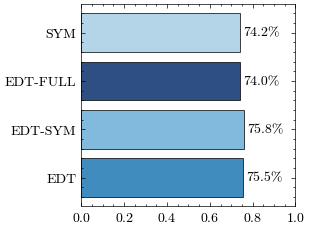

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_horizontal_bars\barh_scoring_full_object_f1_iou_005.svg
Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_horizontal_bars\barh_scoring_full_object_f1_iou_005.png


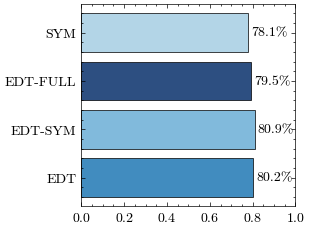

In [6]:
# Full test set horizontal bar figures
plot_horizontal_f1_comparison(
    full_pixel_df,
    scoring_order=SCORING_ORDER,
    output_dir=OUTPUT_DIR,
    xlabel="Mean Pixel F1 Score",
    filename_stem="barh_scoring_full_pixel_f1",
)

plot_horizontal_f1_comparison(
    full_object_df,
    scoring_order=SCORING_ORDER,
    output_dir=OUTPUT_DIR,
    xlabel="Mean Object F1 Score at IoU = 0.05",
    filename_stem="barh_scoring_full_object_f1_iou_005",
)

Stage 1 (pre-merge) EDT-SYM mean Pixel F1: 0.7581
Stage 2 (post-merge) EDT-SYM mean Pixel F1: 0.7578
Stage 2 (post-merge) EDT-SYM mean Object F1@0.05: 0.8095
Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_horizontal_bars\barh_edt_sym_stage1_vs_stage2_f1.svg
Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_horizontal_bars\barh_edt_sym_stage1_vs_stage2_f1.png


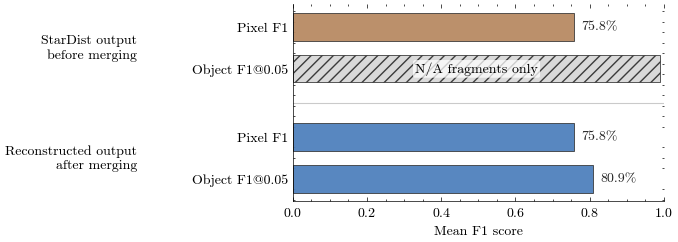

In [7]:
def load_stage1_edt_sym_pixel_f1_mean() -> float:
    """Load Stage-1 (pre-merge) EDT-SYM per-image pixel F1 and return mean."""
    df = read_csv_checked(STAGE1_PIXEL_METRICS_CSV)

    # Flexible column matching for upstream report schema variants.
    run_col = first_existing_column(df, ["run", "run_name", "model", "experiment", "scoring"] )
    f1_col = first_existing_column(df, ["pixel_f1", "Pixel F1", "pixel_f1_score", "F1", "value"] )

    if run_col is None or f1_col is None:
        raise ValueError(
            f"Could not find required columns in {STAGE1_PIXEL_METRICS_CSV}. "
            f"Columns: {df.columns.tolist()}"
        )

    out = df.copy()
    out[run_col] = out[run_col].astype(str).str.strip()
    out[f1_col] = ensure_numeric(out[f1_col])

    stage1 = out.loc[out[run_col].eq(STAGE1_EDT_SYM_RUN_NAME), f1_col].dropna()
    if stage1.empty:
        raise ValueError(
            f"No Stage-1 pixel F1 rows found for run '{STAGE1_EDT_SYM_RUN_NAME}' "
            f"in {STAGE1_PIXEL_METRICS_CSV}"
        )

    return float(stage1.mean())

stage1_pixel_mean = load_stage1_edt_sym_pixel_f1_mean()
stage2_pixel_mean = float(full_pixel_df.loc[full_pixel_df["scoring"].eq("EDT-SYM"), "value"].mean())
stage2_object_mean = float(full_object_df.loc[full_object_df["scoring"].eq("EDT-SYM"), "value"].mean())

print(f"Stage 1 (pre-merge) EDT-SYM mean Pixel F1: {stage1_pixel_mean:.4f}")
print(f"Stage 2 (post-merge) EDT-SYM mean Pixel F1: {stage2_pixel_mean:.4f}")
print(f"Stage 2 (post-merge) EDT-SYM mean Object F1@0.05: {stage2_object_mean:.4f}")

plot_edt_sym_stage_comparison(
    stage1_pixel_mean=stage1_pixel_mean,
    stage2_pixel_mean=stage2_pixel_mean,
    stage2_object_mean=stage2_object_mean,
    output_dir= OUTPUT_DIR,
)

In [2]:
# %%
# Reviewer R2.4:
# Direct whole-CNT StarDist baseline vs NanoVision EDT-SYM.
#
# Values are taken from the five-split benchmark table.
# Reported values are means across the five test splits.
#
# StarDist:
#   - trained directly on whole-CNT GT instances
#   - no fragment merging
#
# NanoVision EDT-SYM:
#   - fragment-based prediction
#   - fragment merging during post-processing
import pandas as pd
R24_COMPARISON = {
    "StarDist": {
        "object_f1_cldice_05": 0.334,
        "object_f1_cldice_05_ci_low": 0.269,
        "object_f1_cldice_05_ci_high": 0.399,
        "pixel_f1": 0.717,
        "pixel_f1_ci_low": 0.697,
        "pixel_f1_ci_high": 0.737,
    },
    "NanoVision EDT-SYM": {
        "object_f1_cldice_05": 0.693,
        "object_f1_cldice_05_ci_low": 0.646,
        "object_f1_cldice_05_ci_high": 0.740,
        "pixel_f1": 0.720,
        "pixel_f1_ci_low": 0.699,
        "pixel_f1_ci_high": 0.741,
    },
}


r24_comparison_df = pd.DataFrame.from_dict(
    R24_COMPARISON,
    orient="index",
)

r24_comparison_df.index.name = "method"

display(r24_comparison_df)

,object_f1_cldice_05,object_f1_cldice_05_ci_low,object_f1_cldice_05_ci_high,pixel_f1,pixel_f1_ci_low,pixel_f1_ci_high
method,,,,,,
StarDist,0.334,0.269,0.399,0.717,0.697,0.737
NanoVision EDT-SYM,0.693,0.646,0.740,0.720,0.699,0.741


Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\notebooks\paper_figures\stardist_whole_cnt_vs_nanovision_fragment_merge.svg
Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\notebooks\paper_figures\stardist_whole_cnt_vs_nanovision_fragment_merge.png


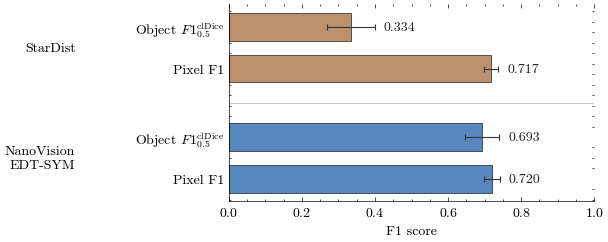

In [9]:
# %%
# Standalone figure for Reviewer R2.4
#
# Direct whole-CNT StarDist vs NanoVision EDT-SYM (fragment + merge).
# All values are hardcoded from the five-split benchmark results.
#
# StarDist:
#   Object F1 clDice@0.5 = 0.334 [0.269, 0.399]
#   Pixel F1             = 0.717 [0.697, 0.737]
#
# NanoVision EDT-SYM:
#   Object F1 clDice@0.5 = 0.693 [0.646, 0.740]
#   Pixel F1             = 0.720 [0.699, 0.741]

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except ImportError:
    pass


# ------------------------------------------------------------------
# Hardcoded results
# ------------------------------------------------------------------

STARDIST_OBJECT_F1 = 0.334
STARDIST_OBJECT_CI = (0.269, 0.399)

STARDIST_PIXEL_F1 = 0.717
STARDIST_PIXEL_CI = (0.697, 0.737)

NANOVISION_OBJECT_F1 = 0.693
NANOVISION_OBJECT_CI = (0.646, 0.740)

NANOVISION_PIXEL_F1 = 0.720
NANOVISION_PIXEL_CI = (0.699, 0.741)


# ------------------------------------------------------------------
# Output
# ------------------------------------------------------------------

OUTPUT_DIR = (
    Path.cwd()
    / "paper_figures"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FILENAME_STEM = (
    "stardist_whole_cnt_vs_nanovision_fragment_merge"
)


# ------------------------------------------------------------------
# Prepare plot data
# ------------------------------------------------------------------

y_positions = np.array([
    3.2,
    2.4,
    1.1,
    0.3,
])

metric_labels = [
    r"Object $F1^{\mathrm{clDice}}_{0.5}$",
    "Pixel F1",
    r"Object $F1^{\mathrm{clDice}}_{0.5}$",
    "Pixel F1",
]

values = np.array([
    STARDIST_OBJECT_F1,
    STARDIST_PIXEL_F1,
    NANOVISION_OBJECT_F1,
    NANOVISION_PIXEL_F1,
])

ci_low = np.array([
    STARDIST_OBJECT_CI[0],
    STARDIST_PIXEL_CI[0],
    NANOVISION_OBJECT_CI[0],
    NANOVISION_PIXEL_CI[0],
])

ci_high = np.array([
    STARDIST_OBJECT_CI[1],
    STARDIST_PIXEL_CI[1],
    NANOVISION_OBJECT_CI[1],
    NANOVISION_PIXEL_CI[1],
])

xerr = np.vstack([
    values - ci_low,
    ci_high - values,
])

colors = [
    "#B88A63",
    "#B88A63",
    "#4F81BD",
    "#4F81BD",
]


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

# Same figure size as the previous stage-comparison figure.
fig, ax = plt.subplots(
    figsize=(5.8, 2.7),
)

bars = ax.barh(
    y_positions,
    values,
    height=0.52,
    color=colors,
    edgecolor="#333333",
    linewidth=0.6,
    alpha=0.95,
    xerr=xerr,
    error_kw={
        "ecolor": "#333333",
        "elinewidth": 0.8,
        "capsize": 2.5,
        "capthick": 0.8,
    },
)


# ------------------------------------------------------------------
# Metric labels
# ------------------------------------------------------------------

ax.set_yticks(y_positions)
ax.set_yticklabels(metric_labels)


# ------------------------------------------------------------------
# Method labels
# ------------------------------------------------------------------

ax.text(
    -0.42,
    np.mean(y_positions[:2]),
    "StarDist",
    ha="right",
    va="center",
    fontweight="bold",
    transform=ax.get_yaxis_transform(),
)

ax.text(
    -0.42,
    np.mean(y_positions[2:]),
    "NanoVision\nEDT-SYM",
    ha="right",
    va="center",
    fontweight="bold",
    transform=ax.get_yaxis_transform(),
)


# ------------------------------------------------------------------
# Divider
# ------------------------------------------------------------------

ax.axhline(
    y=1.75,
    color="#BDBDBD",
    linewidth=0.8,
    linestyle="-",
    alpha=0.8,
)


# ------------------------------------------------------------------
# Numerical mean values
#
# Position each value AFTER the upper end of its 95% CI so that
# the text does not overlap the uncertainty range.
# ------------------------------------------------------------------

TEXT_PADDING = 0.025

for bar, value, upper_ci in zip(
    bars,
    values,
    ci_high,
):
    y = (
        bar.get_y()
        + bar.get_height() / 2
    )

    text_x = upper_ci + TEXT_PADDING

    ax.text(
        text_x,
        y,
        f"{value:.3f}",
        va="center",
        ha="left",
        color="#222222",
    )


# ------------------------------------------------------------------
# Axes
# ------------------------------------------------------------------

ax.set_xlim(0, 1)
ax.set_xlabel("F1 score")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="y",
    length=0,
)

ax.tick_params(
    axis="x",
    direction="in",
)

ax.set_axisbelow(True)

plt.subplots_adjust(
    left=0.35,
    right=0.98,
    bottom=0.22,
    top=0.95,
)


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

svg_path = (
    OUTPUT_DIR
    / f"{FILENAME_STEM}.svg"
)

png_path = (
    OUTPUT_DIR
    / f"{FILENAME_STEM}.png"
)

fig.savefig(
    svg_path,
    format="svg",
    bbox_inches="tight",
    pad_inches=0.02,
)

fig.savefig(
    png_path,
    format="png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02,
)

print(f"Saved: {svg_path}")
print(f"Saved: {png_path}")

plt.show()